In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../python')
import threepoint

# Plot Map3
This is to plot the Map3 signal measured from CosmoGrid sims. Bhuv requested this plot for presentation on May 19.

In [2]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/map3_dv_COSMOGRID_19Apr24.fits')

In [3]:
zbins = thpt.get_z_bin(unique=True).T

In [4]:
sel = thpt.selection_z_bin(zbins[-1], 'z123')

sig = thpt.get_signal(sel)
std = thpt.get_std(sel)
t = thpt.get_t_bin(sel)[0]

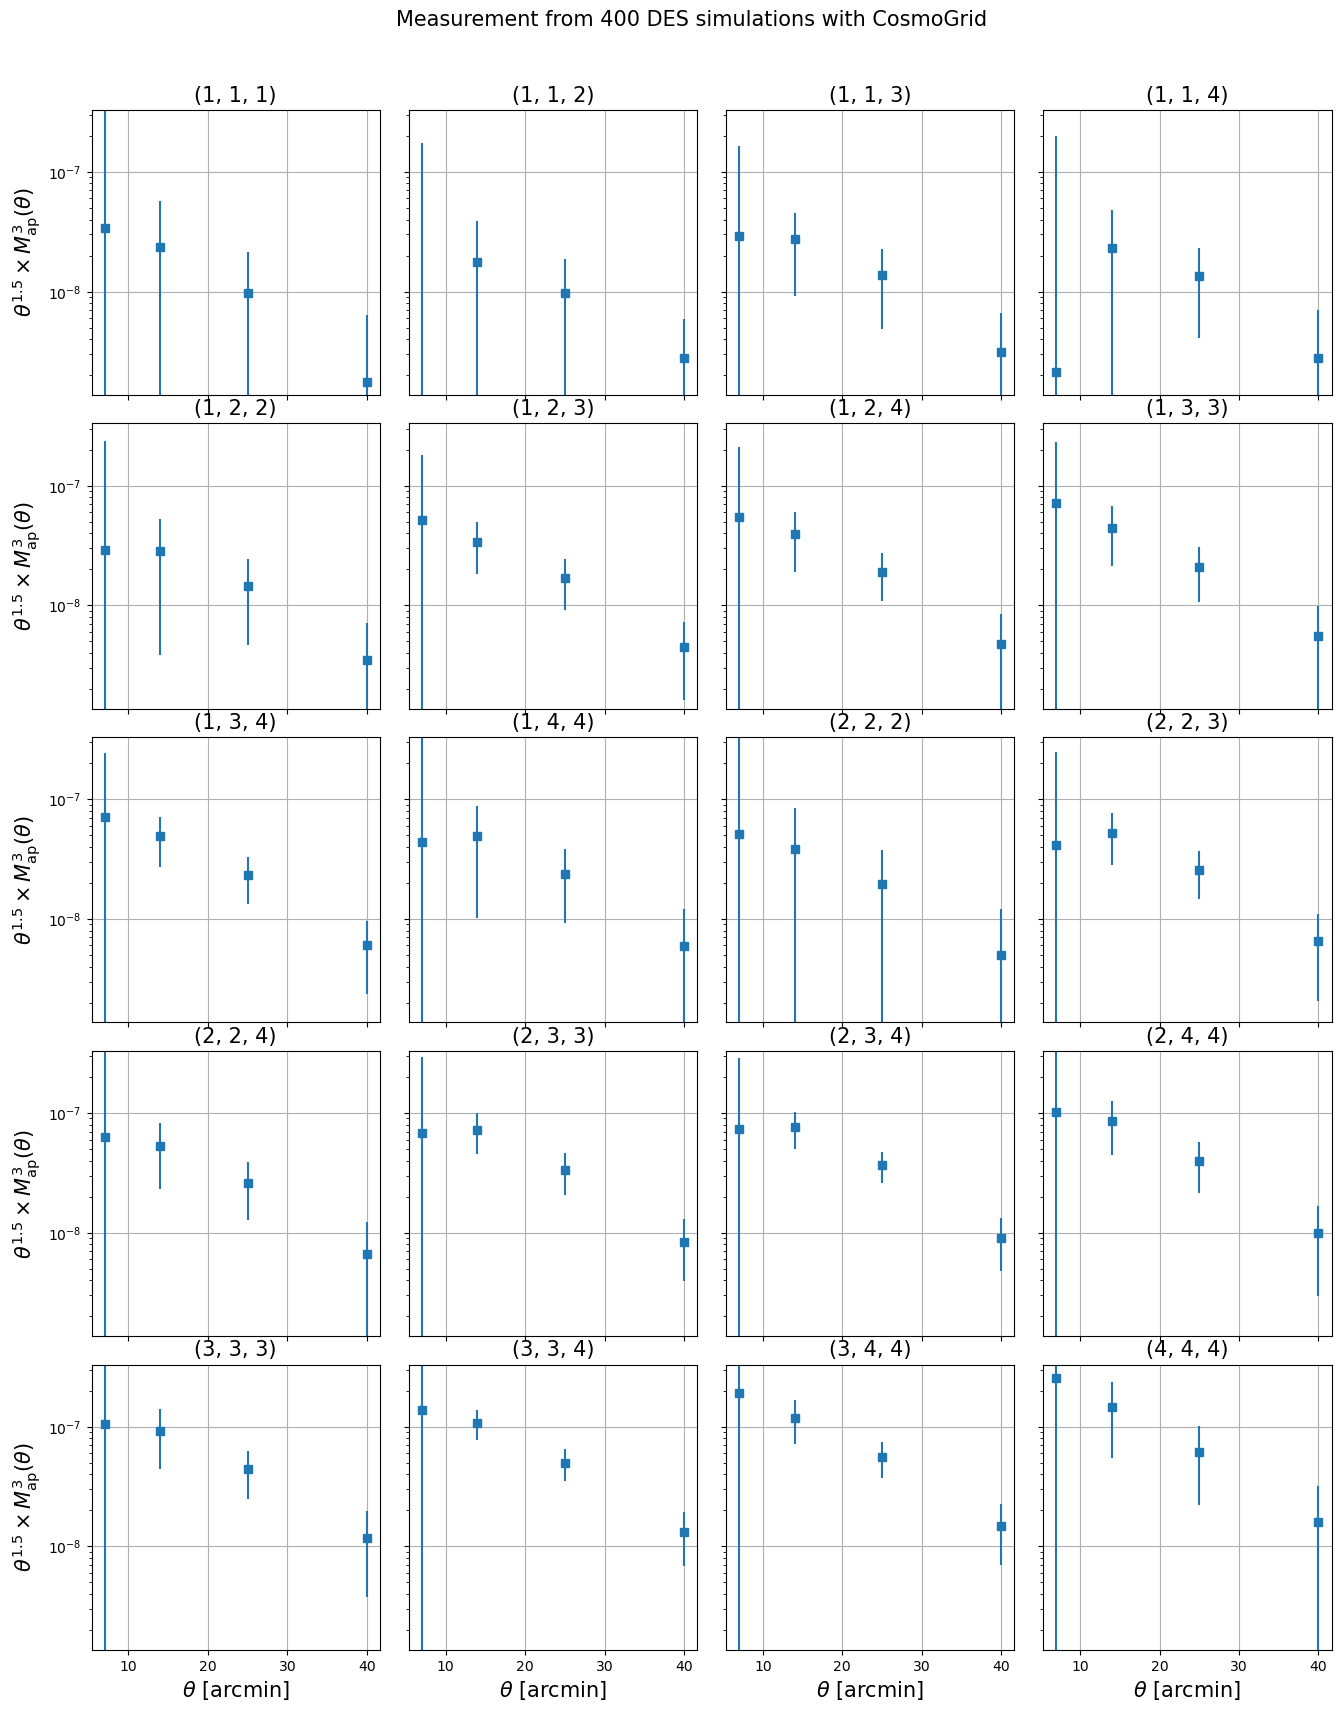

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(16, 20), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
fs = 15
t_sidx = 1.5

fig.suptitle('Measurement from 400 DES simulations with CosmoGrid', fontsize=fs, y=0.93)
for i, ax in enumerate(axes.flatten()):
    sel = thpt.selection_z_bin(zbins[i], 'z123')
    sig = thpt.get_signal(sel)
    std = thpt.get_std(sel)
    t = thpt.get_t_bin(sel)[0]

    z1, z2, z3 = zbins[i]

    ax.set_yscale('log')
    ax.errorbar(t, t**t_sidx*sig, yerr=t**t_sidx*std, fmt='s')
    ax.set_title('({}, {}, {})'.format(z1, z2, z3), fontsize=fs)

    ax.grid()
    if i % 4 == 0:
        ax.set_ylabel(r'$\theta^{{{}}} \times M_{{\rm ap}}^3(\theta)$'.format(t_sidx), fontsize=fs)
    if i >= 16:
        ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=fs)

plt.show()